# 1. Introduction & Research Questions: Analysing the Evolution of Spotify Music (2015–2025)

This project investigates how the sound and popularity of mainstream music have changed on Spotify between 2015 and 2025. Inspired by James Cutting’s work on the evolution of Hollywood films, I focus on three main questions:

1. Have audio features such as danceability, energy, tempo, instrumentalness, and loudness…”) changed over time?
2. Can a simple linear model capture long-term trends in these features?
3. To what extent can audio features predict track popularity on Spotify?

Using the **Spotify Music Analytics Dataset (2015–2025)**, I apply exploratory data analysis, descriptive statistics, and linear regression models to examine temporal trends and relationships between variables. The analysis follows the structure of the course notebooks (Weeks 1–3 and Week 5), adapting techniques such as data summarisation, groupby statistics, and regression modelling to the domain of music analytics.

The results provide a data-driven perspective on how streaming-era music has evolved and what kinds of sonic characteristics are associated with higher popularity. I also reflect on the limitations of the dataset and what aspects of musical experience are not captured by numerical audio features.

# 2. Data Exploration and Preparation
# 2.1 Loading and Initial Inspecting


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

# Set the maximum number of rows displayed in the DataFrame to 100
# rows
pd.set_option('display.max_rows', 100)
# columns
pd.set_option('display.max_columns', 100)
# Set the floating-point display format to keep 5 decimal places
pd.set_option('display.float_format', '{:.5f}'.format)
# Set the print options for the NumPy array
np.set_printoptions(suppress=True)

# read spotify_2015_2025 dataframe
file_path = r'C:\Users\wangxinxin\Documents\GitHub\Data_Science_for_Creative_Industry_project_Xin_Wang\data\spotify_2015_2025_85k.csv'
df = pd.read_csv(file_path)

# check head rows and Basic information
df.head()

,track_id,track_name,artist_name,album_name,release_date,genre,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,country,explicit,label
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,Beautiful instead,2016-04-01,Pop,234194,55,0.15000,0.74000,9,-32.22000,0,0.43600,73.12000,13000,Brazil,0,Universal Music
1,TRK-6A32496762D7,Night respond,Jennifer Cole,Table,2022-04-15,Metal,375706,45,0.44000,0.46000,0,-14.02000,0,0.22300,157.74000,1000,France,1,Island Records
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,Page southern,2016-02-23,Rock,289191,55,0.62000,0.80000,8,-48.26000,1,0.58400,71.03000,1000,Germany,1,XL Recordings
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,Spring,2015-10-12,Pop,209484,51,0.78000,0.98000,1,-34.47000,1,0.68400,149.00000,1000,France,0,Warner Music
4,TRK-9245F2AD996A,Husband,Mark Diaz,Great prove,2022-07-08,Indie,127435,39,0.74000,0.18000,10,-17.84000,0,0.30400,155.85000,2000,United States,0,Independent


In [3]:
# check data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85000 entries, 0 to 84999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          85000 non-null  object 
 1   track_name        84979 non-null  object 
 2   artist_name       85000 non-null  object 
 3   album_name        84954 non-null  object 
 4   release_date      85000 non-null  object 
 5   genre             85000 non-null  object 
 6   duration_ms       85000 non-null  int64  
 7   popularity        85000 non-null  int64  
 8   danceability      85000 non-null  float64
 9   energy            85000 non-null  float64
 10  key               85000 non-null  int64  
 11  loudness          85000 non-null  float64
 12  mode              85000 non-null  int64  
 13  instrumentalness  85000 non-null  float64
 14  tempo             85000 non-null  float64
 15  stream_count      85000 non-null  int64  
 16  country           85000 non-null  object

In [4]:
# Check the data in the database for outliers
df.describe()

,duration_ms,popularity,danceability,energy,key,loudness,mode,instrumentalness,tempo,stream_count,explicit
count,85000.00000,85000.00000,85000.00000,85000.00000,85000.00000,85000.00000,85000.00000,85000.00000,85000.00000,85000.00000,85000.00000
mean,254913.82429,48.16289,0.52071,0.50541,5.51599,-27.99930,0.50014,0.39978,129.94835,214354.68235,0.20133
std,95300.23321,14.82975,0.27080,0.27977,3.45407,15.59837,0.50000,0.23147,40.44432,1680637.47015,0.40100
min,90004.00000,0.00000,0.05000,0.02000,0.00000,-55.00000,0.00000,0.00000,60.00000,1000.00000,0.00000
25%,171871.50000,38.00000,0.29000,0.26000,2.75000,-41.47000,0.00000,0.19800,94.84000,1000.00000,0.00000
50%,254920.50000,47.00000,0.52000,0.50000,6.00000,-27.97000,1.00000,0.39900,129.99000,2000.00000,0.00000
75%,337203.25000,57.00000,0.76000,0.75000,9.00000,-14.50000,1.00000,0.60000,165.03000,9000.00000,0.00000
max,420000.00000,100.00000,0.99000,0.99000,11.00000,-1.00000,1.00000,0.80000,200.00000,20000000.00000,1.00000


In [5]:
# Check column names and select key variables
# check columns name
df.columns

Index(['track_id', 'track_name', 'artist_name', 'album_name', 'release_date',
       'genre', 'duration_ms', 'popularity', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'instrumentalness', 'tempo', 'stream_count',
       'country', 'explicit', 'label'],
      dtype='object')

## Overview of data structures and initial statistics
After loading the 2015-2025 Spotify music analysis dataset (85,000 tracks, 19 columns).I find that the core numerical variables are not missing, and only a small amount of trackname/albumname is missing, which does not affect the quantitative analysis.

Numerical statistics show that the average duration of the track is 4.2 minutes, and the average popularity is 48.16 (balanced distribution); The average danceability and energy values are moderate, the average loudness is - 28dB, and the rhythm fluctuates greatly (the music style is diverse). The data has not been deleted at this stage, and the extreme values of the core variables are in the effective range without obvious errors. However, the distribution of playback volume and loudness is large, and the subsequent regression analysis needs to deal with the problems of scaling and outliers.

**Summary**
- The core numerical variables of the dataset are complete, and only a few non-core fields are missing.
- The key indicators reflect the data distribution characteristics (balanced popularity and diverse music styles)
- There are no data errors, but some variables need to be scaled/outlier issues later.

# 2.2 Missing Select the core column for the analysis and check missing value.

In [6]:
# Select the core column for the analysis
cols_selected = [
    "track_id",
    "track_name",
    "artist_name",
    "release_date",
    "genre",
    "country",
    "label",
    "duration_ms",
    "popularity",
    "stream_count",
    "danceability",
    "energy",
    "instrumentalness",
    "tempo",
    "loudness",
    "explicit"
]

df_selected = df[cols_selected].copy()

df_selected.head()

,track_id,track_name,artist_name,release_date,genre,country,label,duration_ms,popularity,stream_count,danceability,energy,instrumentalness,tempo,loudness,explicit
0,TRK-BEBD53DA84E1,Agent every (0),Noah Rhodes,2016-04-01,Pop,Brazil,Universal Music,234194,55,13000,0.15000,0.74000,0.43600,73.12000,-32.22000,0
1,TRK-6A32496762D7,Night respond,Jennifer Cole,2022-04-15,Metal,France,Island Records,375706,45,1000,0.44000,0.46000,0.22300,157.74000,-14.02000,1
2,TRK-47AA7523463E,Future choice whatever,Brandon Davis,2016-02-23,Rock,Germany,XL Recordings,289191,55,1000,0.62000,0.80000,0.58400,71.03000,-48.26000,1
3,TRK-25ADA22E3B06,Bad fall pick those,Corey Jones,2015-10-12,Pop,France,Warner Music,209484,51,1000,0.78000,0.98000,0.68400,149.00000,-34.47000,0
4,TRK-9245F2AD996A,Husband,Mark Diaz,2022-07-08,Indie,United States,Independent,127435,39,2000,0.74000,0.18000,0.30400,155.85000,-17.84000,0


In [7]:
# check null value
missing_values = df_selected.isna().sum()
missing_values

track_id             0
track_name          21
artist_name          0
release_date         0
genre                0
country              0
label                0
duration_ms          0
popularity           0
stream_count         0
danceability         0
energy               0
instrumentalness     0
tempo                0
loudness             0
explicit             0
dtype: int64

In [8]:
# check the proportion of missing values
missing_counts = df_selected.isna().sum()
missing_percent = df_selected.isna().mean() * 100

pd.DataFrame({
    "missing_count" : missing_counts,
    "missing_percent" : missing_percent
}).sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
track_name,21,0.02471
track_id,0,0.00000
artist_name,0,0.00000
release_date,0,0.00000
genre,0,0.00000
country,0,0.00000
label,0,0.00000
duration_ms,0,0.00000
popularity,0,0.00000
stream_count,0,0.00000


In [9]:
# delete missing value
df_clean = df_selected.dropna().copy()
print("Original size:", len(df_selected))
print("Cleaned size:", len(df_clean))

Original size: 85000
Cleaned size: 84979


## Judgment of missing values
First I checked the proportion of missing values. The missing value of trackname is **0.02471**. And trackname is not the core data in my analysis process. So I can judge that dropna() directly has no effect on the overall dataset and subsequent statistical judgments. So I use `df_clean = df_selected.dropna(subset=model_numericcols).copy()`.

In [10]:
# convert release_date to datetime
df_clean["release_date"] = pd.to_datetime(df_clean["release_date"], errors="coerce")

# Year of extraction
df_clean["release_year"] = df_clean["release_date"].dt.year

# check the data after convert and extraction
df_clean[["release_date", "release_year"]].head()

,release_date,release_year
0,2016-04-01,2016
1,2022-04-15,2022
2,2016-02-23,2016
3,2015-10-12,2015
4,2022-07-08,2022


In [11]:
# Check for any errors:
df_clean["release_year"].describe()

count   84979.00000
mean     2019.98815
std         3.16915
min      2015.00000
25%      2017.00000
50%      2020.00000
75%      2023.00000
max      2025.00000
Name: release_year, dtype: float64

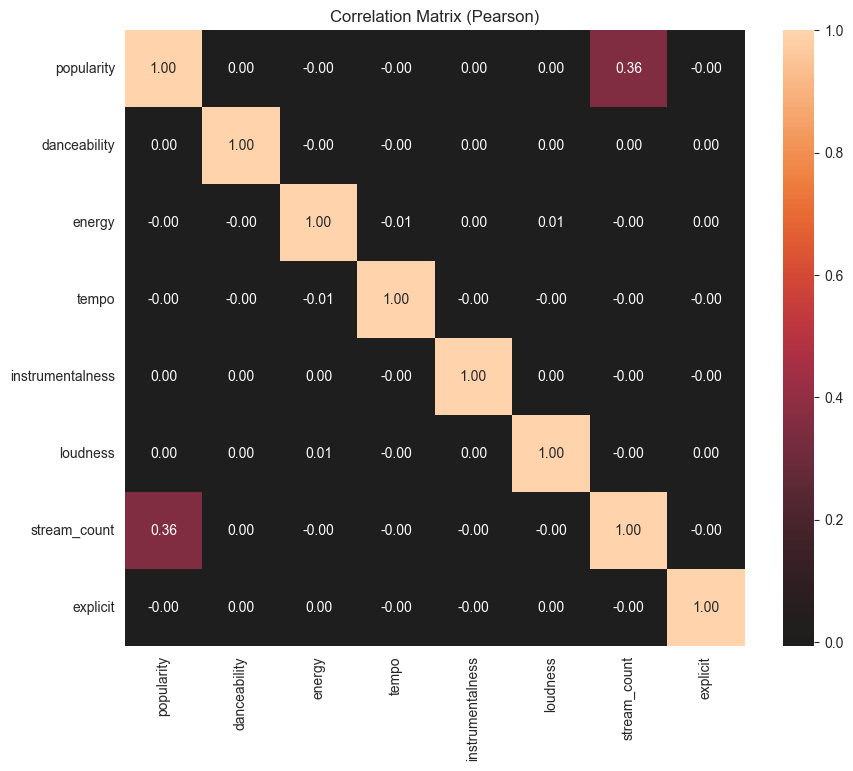

In [12]:
# Pearson Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df_clean[["popularity","danceability","energy","tempo","instrumentalness","loudness","stream_count","explicit"]].corr(method = 'pearson')
sns.heatmap(corr, annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix (Pearson)")
plt.show()

## Correlation Heatmap (Pearson) analysis( The following summary incorporates elements from ChatGPT.)
This Pearson correlation heat map summarizes the linear relationships between the main numerical variables in `analysis_cols`. The results showed that there was a moderate positive correlation between popularity and streamcount (about r=0.36), which was intuitive – songs with higher play volume were also generally more popular. In addition, the correlation coefficient between popularity and each audio feature (`danceability, energy, tempo, instrumentalness, loudness`) is close to 0 as a whole, suggesting that the linear explanatory power of a single audio feature on popularity may be limited. At the same time, there is no very strong linear correlation structure between the audio features (at least in this sample), which provides a preliminary judgment for subsequent multivariate modeling: it is necessary to further test whether the combination of multiple features can improve the predictive power.

Therefore, I organized these core variables into a `df_analysis` dedicated to statistical modeling (composed of `analysis_cols`), and then carried out two analysis paths on this basis: on the one hand, the aggregation of `yearly_features` by year was generated for trend testing; On the other hand, we enter the modeling stage of Part 2, using multivariate regression/feature engineering to evaluate the predictive ability of audio features (as well as streamcount, explicit, etc.) on `popularity`, and perform regression diagnosis and error analysis.

In [14]:
# I build a dataframe dedicated to statistical analysis:
analysis_cols = [
    "release_year",
    "popularity",
    "danceability",
    "energy",
    "instrumentalness",
    "tempo",
    "loudness",
    "stream_count",
    "explicit"
]

df_analysis = df_clean[analysis_cols].copy()

df_analysis.head()

,release_year,popularity,danceability,energy,instrumentalness,tempo,loudness,stream_count,explicit
0,2016,55,0.15000,0.74000,0.43600,73.12000,-32.22000,13000,0
1,2022,45,0.44000,0.46000,0.22300,157.74000,-14.02000,1000,1
2,2016,55,0.62000,0.80000,0.58400,71.03000,-48.26000,1000,1
3,2015,51,0.78000,0.98000,0.68400,149.00000,-34.47000,1000,0
4,2022,39,0.74000,0.18000,0.30400,155.85000,-17.84000,2000,0


## Variable Selection and Data Cleaning summary

To focus the analysis on temporal trends and popularity modelling, I selected a subset of columns containing:

- time information (`release_date`)
- popularity and streaming metrics (`popularity`, `stream_count`)
- core audio features (`danceability`, `energy`, `instrumentalness`, `tempo`, `loudness`)
- contextual variables (`genre`, `country`, `label`, `explicit`)

Following the data cleaning approach introduced in Week 2, I checked for missing values and removed any rows with missing numerical variables required for modelling. The dataset remains structurally complete after cleaning, indicating that the numerical audio features and popularity metrics are consistently recorded.

The release date was converted to datetime format and a new variable, `release_year`, was extracted to enable temporal trend analysis.

# 2.3 Feature Engineering (log transform, year extraction)

The raw distribution of `stream_count` shows a significant long tail, and a few songs have extremely high playback volumes, which can lead to visualizations being dominated by outliers, and also make linear regression very sensitive to outliers. So I did a `log10` transformation (generating `log_stream_count`) on `stream_count` to compress the scale, improve the readability of the distribution, and provide more stable input features for the popularity prediction modeling in Part 2.

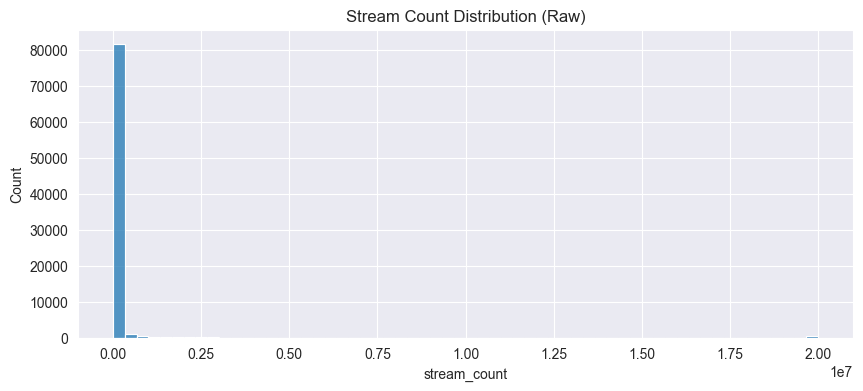

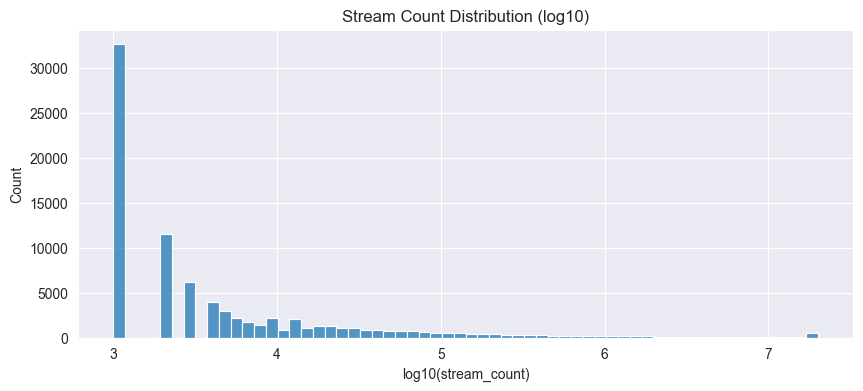

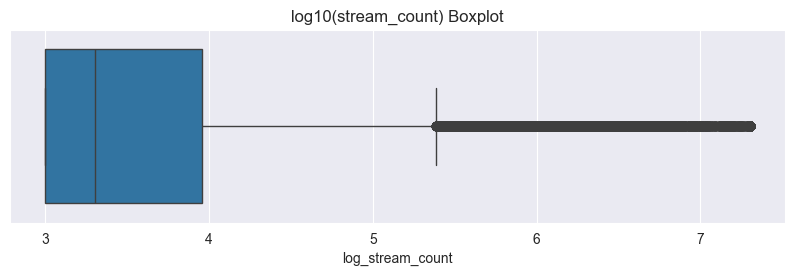

In [15]:
# Do a log10 transformation on stream_count
df_analysis["log_stream_count"] = np.log10(df_analysis["stream_count"])
# Raw distribution
plt.figure(figsize=(10, 4))
sns.histplot(df_analysis["stream_count"], bins=60)
plt.title("Stream Count Distribution (Raw)")
plt.xlabel("stream_count")
plt.show()

# Log distribution
plt.figure(figsize=(10,4))
sns.histplot(df_analysis["log_stream_count"], bins=60)
plt.title("Stream Count Distribution (log10)")
plt.xlabel("log10(stream_count)")
plt.show()

plt.figure(figsize=(10,2.5))
sns.boxplot(x=df_analysis["log_stream_count"])
plt.title("log10(stream_count) Boxplot")
plt.show()

## log10 transformation on stream_count analysis
These two graphs show that the distribution of `stream_count` is extremely long-tailed: most songs are crowded in the low playback area at the original scale, and tens of millions of hits "flatten" the histogram to make it almost unreadable; After doing the log10 transformation, the body distribution is stretched out and clearer, but the box plot still shows obvious right tail and high value outliers. Therefore, subsequent analysis and modeling are more suitable for using `log_stream_count` to reduce the impact of outliers.

# 3.  Audio Feature Evolution (2015-2025)
# 3.1 Sample Balance Verification

## Check Year sample size balance
Check if the annual sample size difference is balanced to avoid annual mean changes that may be due to a particularly small amount of data in a given year or a particular bias towards certain genres.

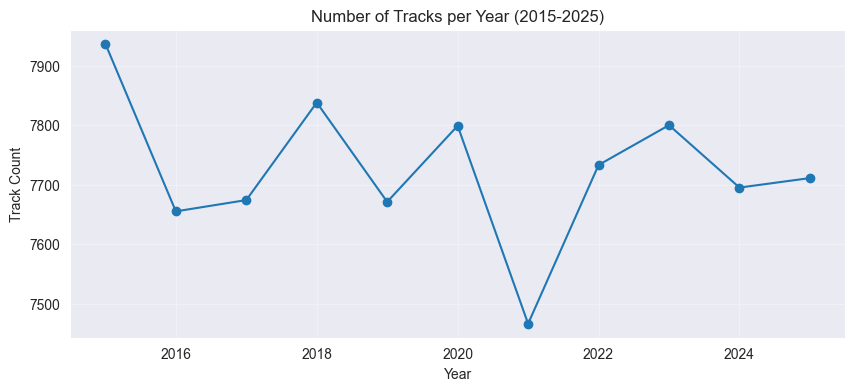

release_year
2015    7937
2016    7655
2017    7674
2018    7838
2019    7671
2020    7799
2021    7466
2022    7733
2023    7800
2024    7695
2025    7711
Name: count, dtype: int64

In [16]:
year_counts = df_analysis["release_year"].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(year_counts.index, year_counts.values, marker="o")
plt.title("Number of Tracks per Year (2015-2025)")
plt.xlabel("Year")
plt.ylabel("Track Count")
plt.grid(True, alpha=0.3)
plt.show()

year_counts

## Number of Tracks per Year (2015–2025) analysis
This chart shows the number of song samples in the dataset for each year from 2015 to 2025. Overall, the number of tracks per year fluctuated within a relatively stable range, without any extreme cases. This indicates that the dataset covers a fairly even time span, and thus the overall trend is not significantly distorted due to insufficient samples in certain years. Although there were some minor declines and increases in certain years, these fluctuations were within reasonable limits and were more likely due to normal sampling variations rather than issues with data quality.

Building on this: Since the overall number of samples per year remains relatively stable, we can more confidently aggregate the data on an annual basis to create `yearly_features` (annual average tables). This allows us to shift our analysis from the level of individual song-level fluctuations to a broader perspective of annual trends, thus preparing us for subsequent trend visualization and linear regression analyses

# 3.2 Yearly Aggregation

In [17]:
# Since you want to see the overall trend rather than individual differences, you need groupby.
# Calculate the annual average audio characteristics by year
yearly_features = (
    df_analysis
    .groupby("release_year")[[
        "danceability",
        "energy",
        "tempo",
        "instrumentalness",
        "popularity",
        "loudness"
    ]]
    .mean()
    .reset_index()
)

yearly_features.head(10)

,release_year,danceability,energy,tempo,instrumentalness,popularity,loudness
0,2015,0.52477,0.51059,129.86019,0.39632,48.23145,-27.77200
1,2016,0.52058,0.50282,130.72088,0.39827,47.98615,-27.93136
2,2017,0.51610,0.50394,130.30474,0.40204,47.99909,-28.12553
3,2018,0.52220,0.50597,129.87261,0.39796,48.07693,-28.22612
4,2019,0.51801,0.50457,130.39694,0.39808,47.95033,-28.13242
5,2020,0.51936,0.50234,129.23378,0.40538,48.22080,-28.14173
6,2021,0.52398,0.50477,130.02954,0.40106,48.44750,-27.80840
7,2022,0.52303,0.50873,129.93571,0.39983,48.14225,-28.08978
8,2023,0.52108,0.50619,129.41410,0.40098,48.28987,-27.78094
9,2024,0.51451,0.50316,129.83426,0.40124,48.23262,-27.93092


### Selection of Core Audio Features

The selected features—danceability, energy, tempo, instrumentalness, and popularity—represent key dimensions of musical structure and market performance.

- `Danceability` captures rhythmic stability and bodily engagement.
- `Energy` reflects intensity and dynamic activity.
- `Tempo` measures speed in beats per minute.
- `Instrumentalness` indicates the presence or absence of vocals.
- `Popularity` provides a platform-based indicator of commercial success.

Together, these variables allow the analysis to explore both sonic evolution and market outcomes in the streaming era.

### Aggregation by Year

Rather than modelling individual tracks directly, I aggregate audio features at the yearly level. With 85,000 tracks in the dataset, track-level variation is substantial and may obscure macro-level stylistic trends.

By computing yearly averages, I shift the analysis from micro-level variation (individual songs) to macro-level cultural patterns (yearly tendencies). This approach reduces noise, ensures equal weighting across years, and better aligns with the research question concerning long-term stylistic change between 2015 and 2025.

# 3.3 Trend Analysis (6 features)

**After establishing the screening of the main features, I want to check the Pearson values and r² of several features. Each feature is based on the annual average. The code in the cell below is completed using the code on `Making Model` in the week 5 course notebook and the assistance of Chatgpt.**

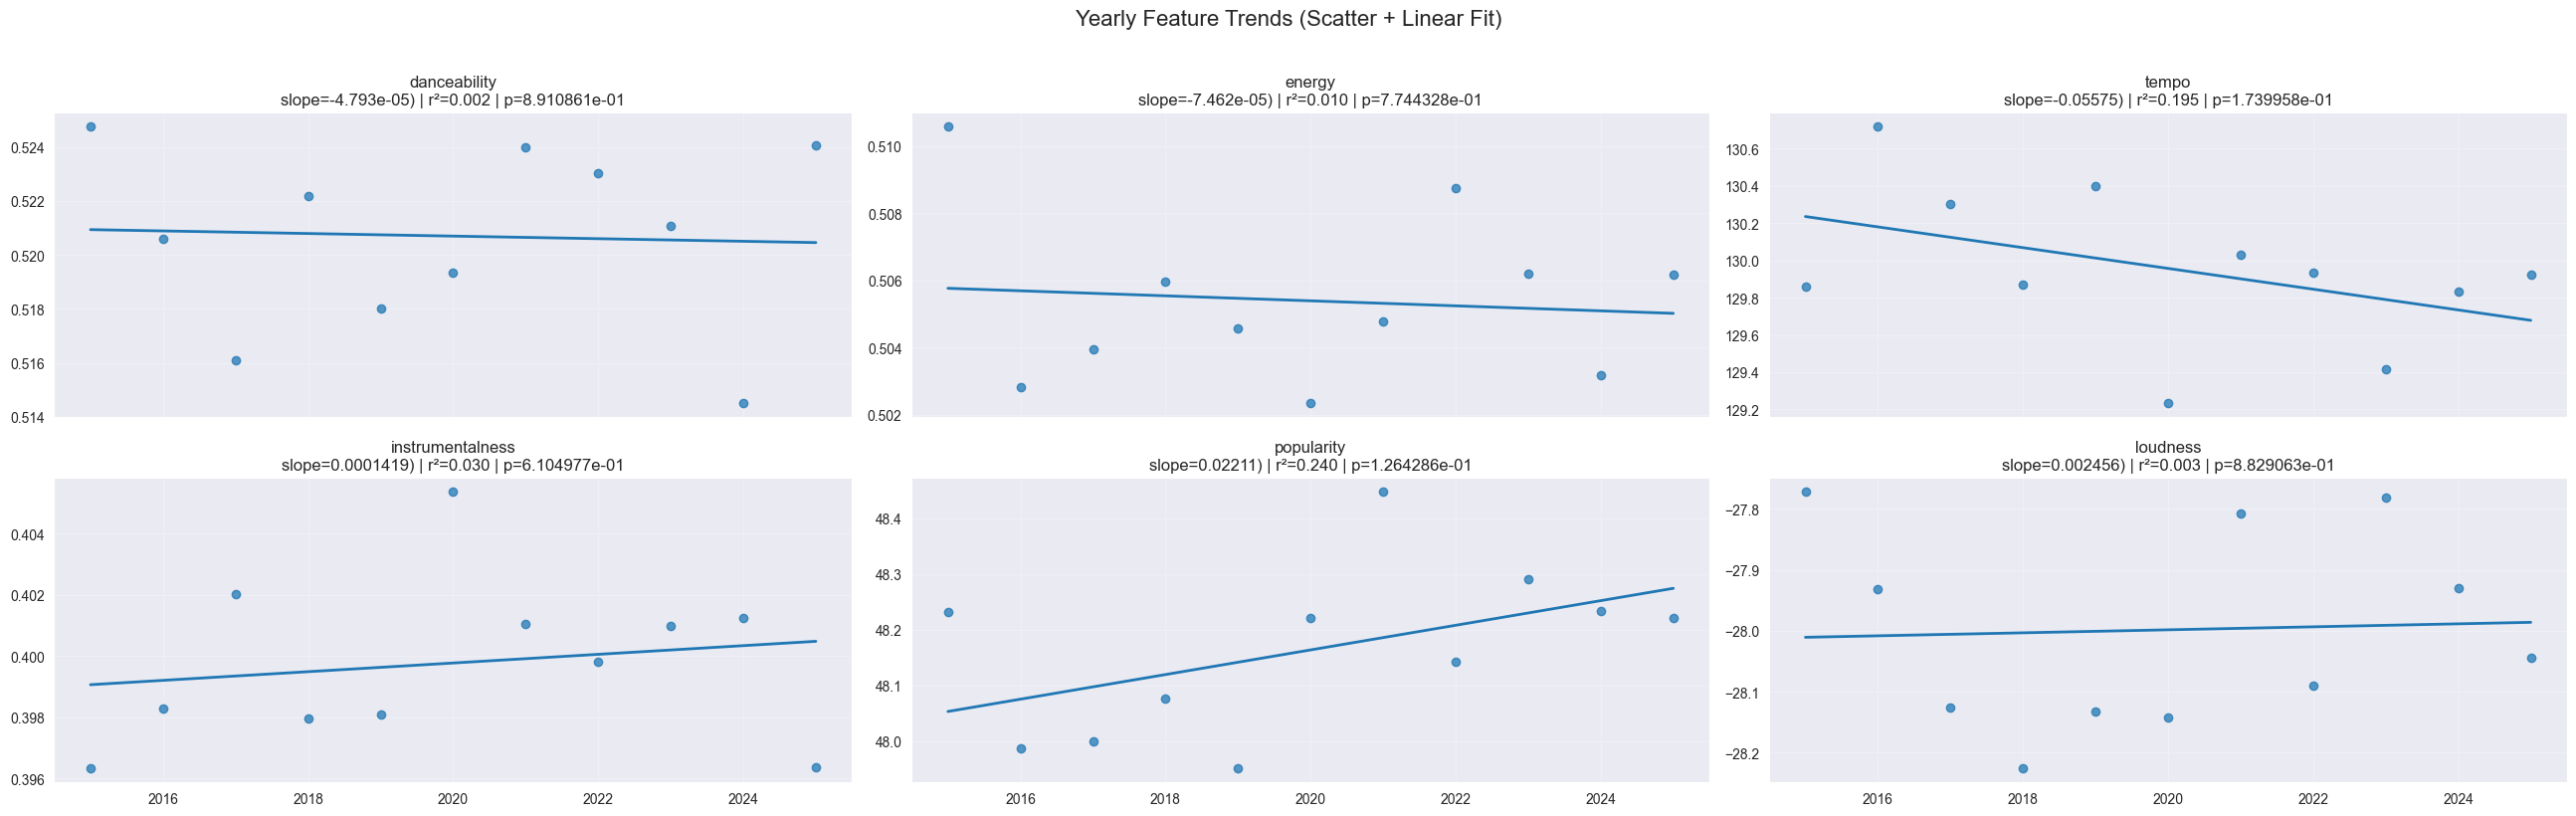


Trend Test Results:
            feature    slope  intercept        r  r_squared  p_value  std_err
0      danceability -0.00005    0.61751 -0.04690    0.00220  0.89109  0.00034
1            energy -0.00007    0.65611 -0.09800    0.00960  0.77443  0.00025
2             tempo -0.05575  242.57747 -0.44150    0.19490  0.17400  0.03777
3  instrumentalness  0.00014    0.11321  0.17320    0.03000  0.61050  0.00027
4        popularity  0.02211    3.49596  0.48950    0.23960  0.12643  0.01313
5          loudness  0.00246  -32.95885  0.05040    0.00250  0.88291  0.01621


In [23]:
# Trend Test Table : scipy.stats.linregress()

trend_features = ["danceability", "energy", "tempo", "instrumentalness", "popularity", "loudness"]

trend_results = []
x = yearly_features["release_year"].values

fig, axes = plt.subplots(2, 3, figsize=(26, 8), sharex=True)
axes = axes.ravel()

for i, feat in enumerate(trend_features):
    ax = axes[i]
    y = yearly_features[feat].values

    slope, intercept, r, p, std_err = st.linregress(x, y)

    trend_results.append({
        "feature": feat,
        "slope": slope,
        "intercept": intercept,
        "r": r,
        "r_squared": r**2,
        "p_value": p,
        "std_err": std_err
    })


    # scatter
    ax.scatter(x, y, alpha=0.75)

    # regression line
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, linewidth=2)

    # title with stats
    ax.set_title(f"{feat}\nslope={slope:.4g}) | r²={r**2:.3f} | p={p:2e}")
    ax.grid(True, alpha=0.25)

fig.suptitle("Yearly Feature Trends (Scatter + Linear Fit)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

trend_results_df = pd.DataFrame(trend_results)
print("\nTrend Test Results:")
print(trend_results_df.round({
    "slope": 6,
    "intercept": 6,
    "r": 4,
    "r_squared": 4,
    "p_value": 6,
    "std_err": 6
}))

## Trend Test Table analysis (In the following summary, some analysis results provided by ChatGPT regarding this chart have been incorporated.)
This graph shows the annual mean scatter of **6 indicators (danceability, energy, tempo, instrumentalness, popularity, loudness)** and the corresponding linear regression fitting line (linregress output slope, R², p-value)  6 indicators (danceability, energy, tempo, instrumentalness, popularity, loudness) from 2015 to 2025. Overall, **most of the fit lines are close to the level, indicating that these audio characteristics have changed little over the past decade.** At the same time, all features had **p-values greater than 0.05, so there was insufficient statistical evidence to support "a significant linear long-term trend".**

The main difference between the different characteristics is the trend direction and strength: **popularity shows the most obvious signs of an increase (slope≈0.022/year) and has the largest R² (≈0.240) and the smallest p-value (≈0.126) among this set of variables, so it is the "relative most significant" feature**; This is followed by tempo, which shows a downward trend (slope≈-0.056/year, R²≈0.195, p≈0.174). In contrast, the R² of danceability, energy, and loudness is close to 0 and the p-value is large, indicating that the year can hardly explain their changes, and the overall is closer to the steady state. Instrumentality has risen slightly, but the trend is also weak and insignificant.

The reason for using `yearly_features` (the average aggregated by year) is because the individual song level varies greatly (different genres, countries, and labels will introduce strong noise), and directly using 85,000 songs as a trend map will "drown" the long-term trend. Annual aggregation can reduce noise and highlight macro changes, which is more in line with the research question's focus on "ten-year scale style evolution", and also makes visualization and regression results easier to interpret.

# 3.4 Distribution Analysis (Boxplot/Violin)
However, using only averages masks true differences in the data. For example, stylistic changes brought about by certain music genres or regions cannot be reflected in the average. Therefore, separate analysis will be carried out for different music genres in the future. **The following cell unit is suggested by ChatGPT to use box plots and violin diagrams to check whether the distribution during the year is "more concentrated, more scattered, and has a longer tail". The code is generated by ChatGPT.**

Annual average data shows only small changes over time, while box plots or violin plots reveal changes over the year. These charts help distinguish between "no change in the average" and "change in data distribution patterns" - such as increased data fragmentation, increased tail distribution, or a shift in quartiles. In other words, while the overall data shows stability at a macro level, there may still be significant structural differences at the specific track level.


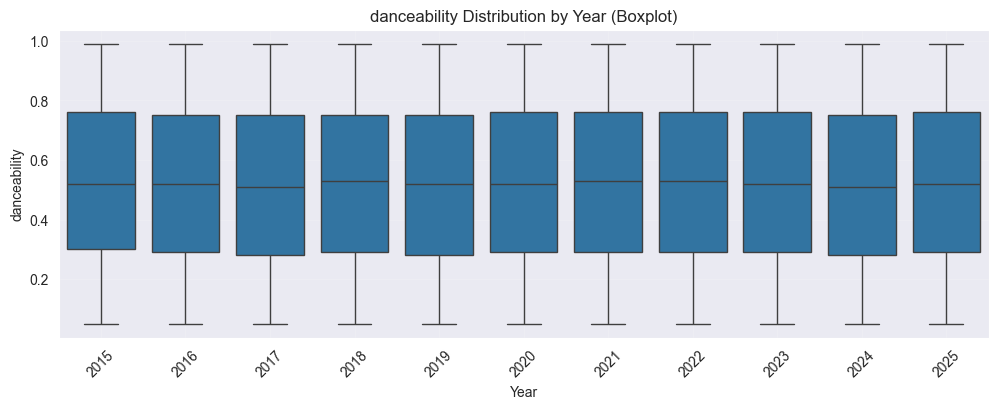

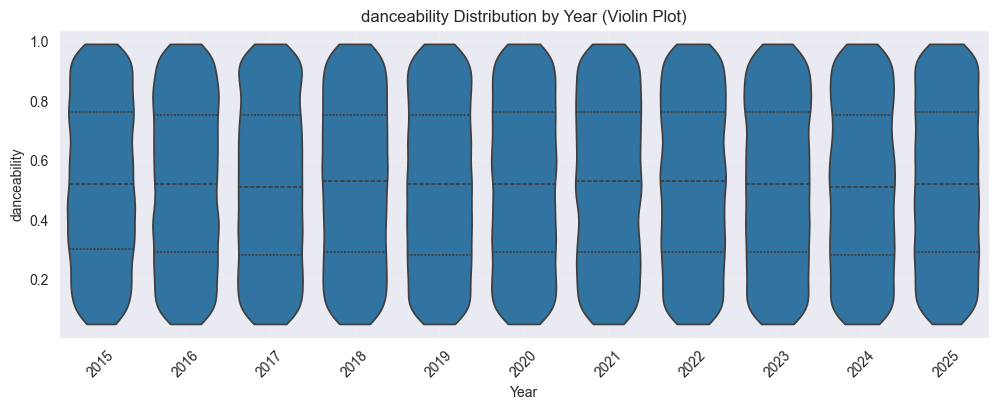

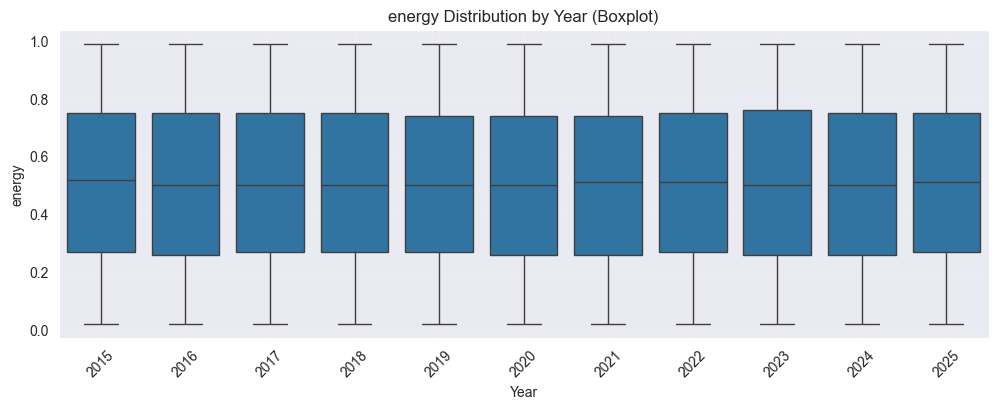

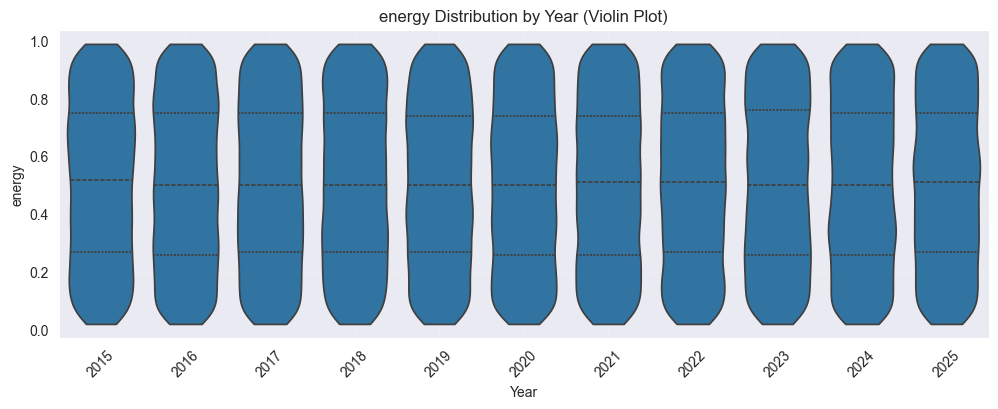

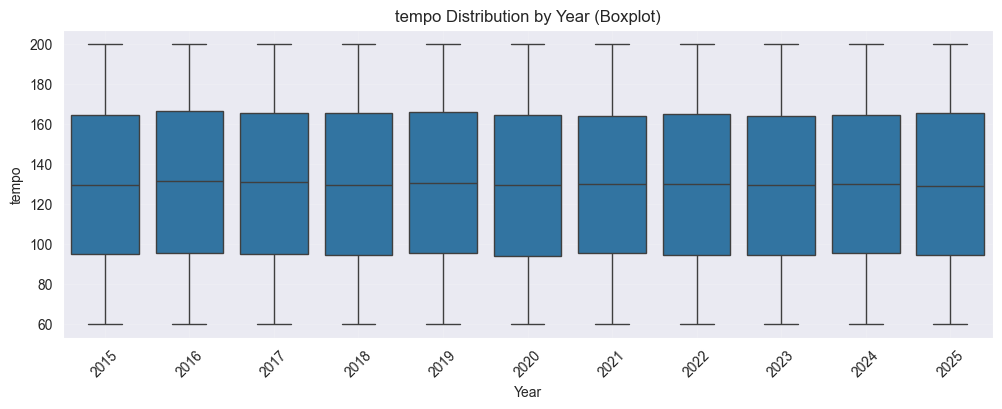

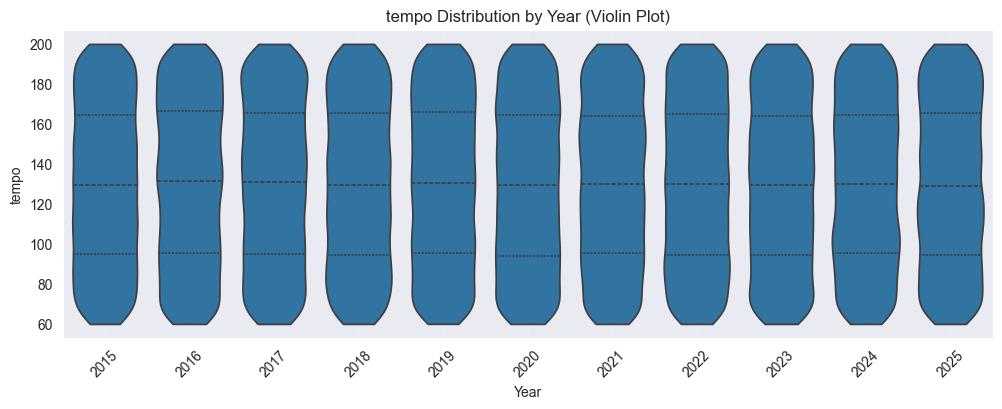

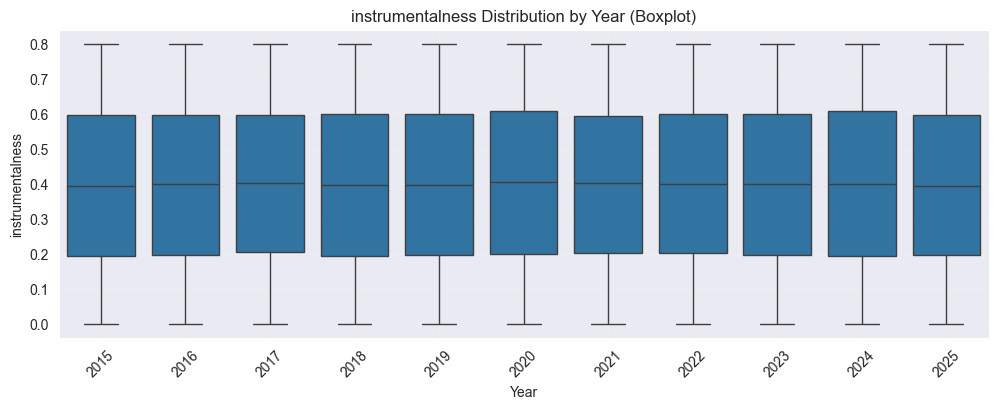

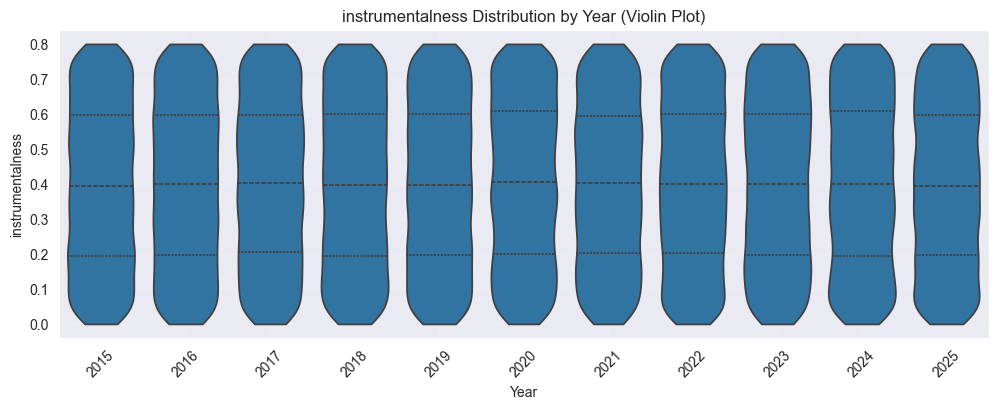

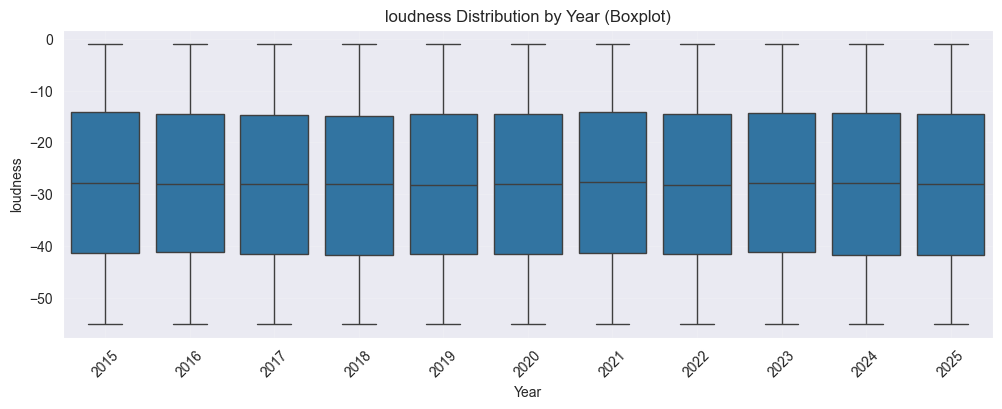

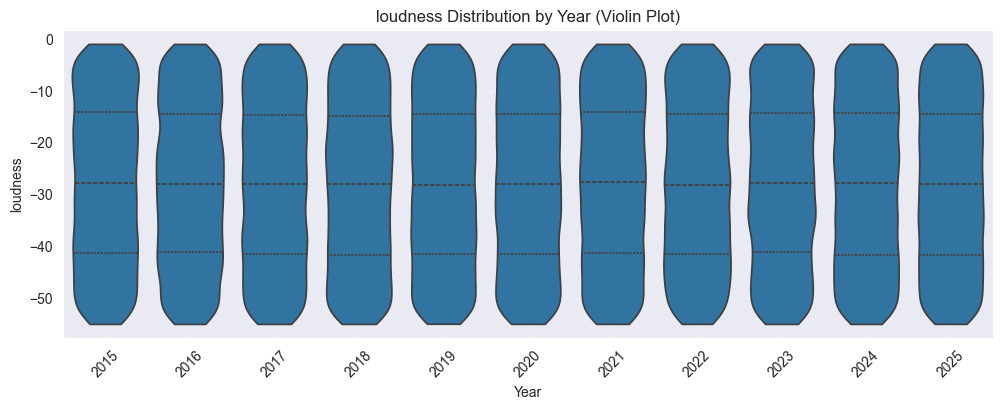

In [19]:
#  Boxplot + Violin
features_dist = ["danceability", "energy", "tempo", "instrumentalness", "loudness"]

for feat in features_dist:
    plt.figure(figsize=(12,4))
    sns.boxplot(data=df_clean, x="release_year", y=feat)
    plt.title(f"{feat} Distribution by Year (Boxplot)")
    plt.xlabel("Year")
    plt.ylabel(feat)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.15)
    plt.show()

    plt.figure(figsize=(12,4))
    sns.violinplot(data=df_clean, x="release_year", y=feat, inner="quartile", cut=0)
    plt.title(f"{feat} Distribution by Year (Violin Plot)")
    plt.xlabel("Year")
    plt.ylabel(feat)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.15)
    plt.show()


## Boxplot + Violin analysis
**2015–2025 The distribution shape of each feature is very stable**, with little change in median and interquartile range from year to year, and the density morphology of the violin graph is largely consistent, indicating that there is no significant structural migration of these audio features over a decade. Specifically, the annual distribution of danceability, energy, instrumentalness, and loudness is almost unchanged. Although the tempo showed slight signs of decline in mean reversion, the change was still relatively modest from the distribution level. At the same time, loudness has always had a wide range of values, with cue differences coming more from the coexistence of different styles/production strategies than from the systematic variation caused by the year.

Because the distribution is generally stable but internal differences persist, the next step is to group by genre (and optionally country/label) to test for mixing effects of "genres changing in different directions and being masked by the population mean".

# 3.5 Genre-Grouped Trends

In [43]:
# Genre-Grouped Trends (Top Genres)
# View the distribution of sample sizes across different genres.
genre_counts = df_clean["genre"].value_counts()
genre_counts.head(10)

genre
Metal        7199
Jazz         7175
Hip-Hop      7159
Classical    7157
Rock         7111
Pop          7095
R&B          7083
Folk         7079
Country      7026
Indie        7003
Name: count, dtype: int64

In [45]:
# Only the Top n with the largest sample size are selected
top_n = 5
top_genres = genre_counts.head(top_n).index.tolist()

# Aggregate by year
genre_yearly = (
    df_clean[df_clean["genre"].isin(top_genres)]
    .groupby(["release_year", "genre"])[["danceability", "energy", "tempo"]]
    .mean()
    .reset_index()
)

genre_yearly.head()

,release_year,genre,danceability,energy,tempo
0,2015,Classical,0.50927,0.51094,130.82701
1,2015,Hip-Hop,0.53187,0.50444,129.20903
2,2015,Jazz,0.51758,0.51498,129.74441
3,2015,Metal,0.51233,0.51242,131.32437
4,2015,Rock,0.53078,0.51911,129.60770


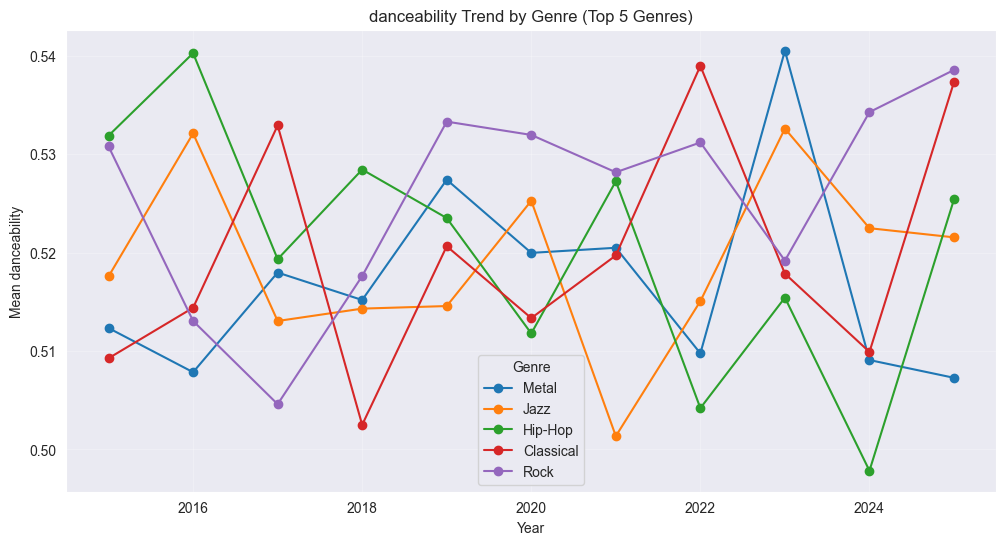

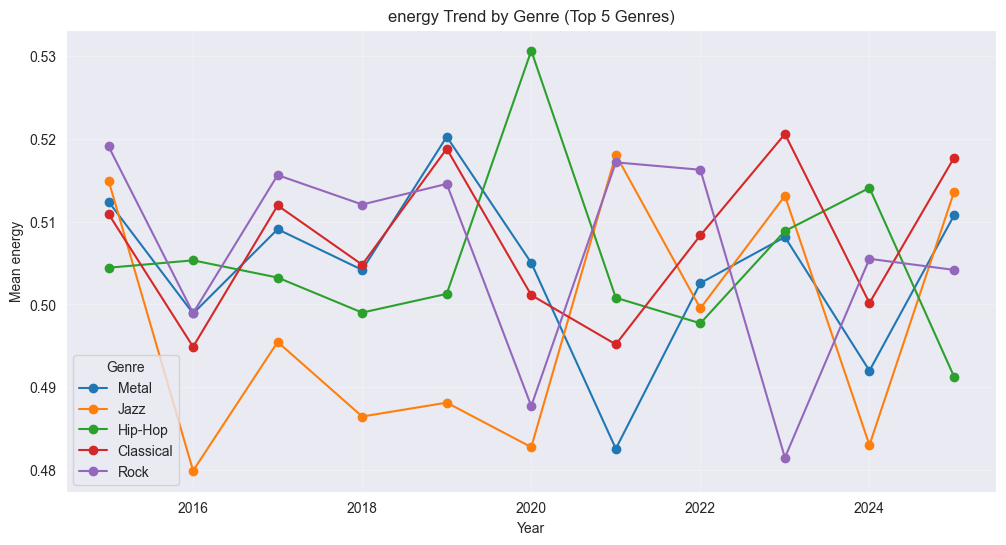

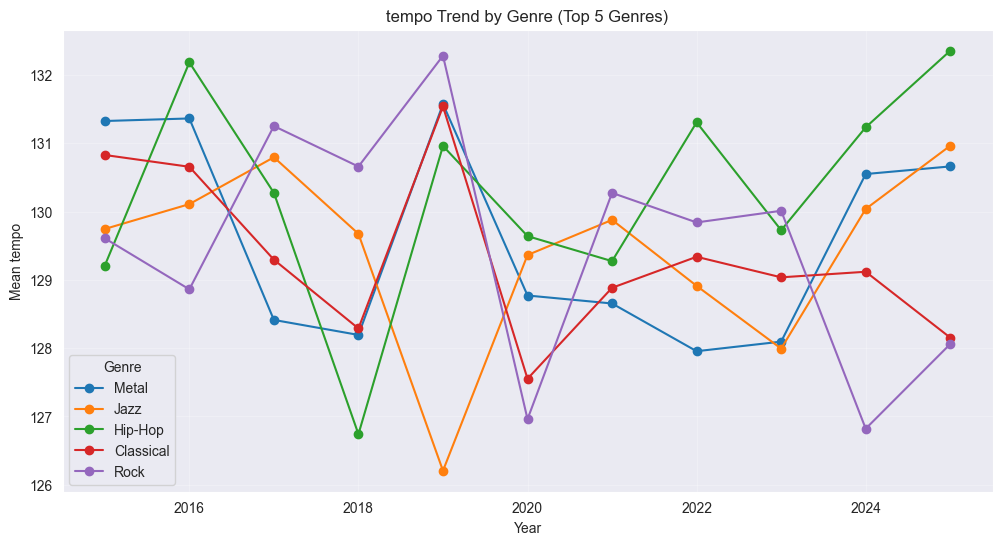

In [46]:
# Draw trends by genre grouping
features_to_plot = ["danceability", "energy", "tempo"]

# Draw multiple graphs with a for loop(modify the code in conjunction with the lesson)
for feat in features_to_plot:
    plt.figure(figsize=(12,6))
    for g in top_genres:
        sub = genre_yearly[genre_yearly["genre"] == g]
        plt.plot(sub["release_year"], sub[feat], marker="o", label=g)

    plt.title(f"{feat} Trend by Genre (Top {top_n} Genres)")
    plt.xlabel("Year")
    plt.ylabel(f"Mean {feat}")
    plt.grid(True, alpha=0.25)
    plt.legend(title="Genre")
    plt.show()

## Top 5 Genres analysis(The following is a summary of Chatgpt.)
After splitting by genre, all three characteristics showed obvious differentiation, indicating that the **stability** of the overall mean may come from the mutual cancellation of the rise and fall of different genres.

- Danceability: Rock overall higher after 2017 and remain high in 2024–2025; Hip-Hop declined significantly after 2022, the lowest in 2024, and rebounded in 2025; Metal 2023 rose and then retreated; Classical has high points in 2022 and 2025; Jazz is relatively smooth.

- Energy: Fluctuating around 0.50 overall, but fluctuations within genres are obvious: Hip-Hop fell back after peaking in 2020; Rock rebounded after a significant decline in 2023; Metal recovered after a low in 2021.

- Tempo: The strongest differentiation. Hip-Hop continued to rise in 2022–2025 after a low in 2018 and peaked in 2025; Rock 2019 highs fall and bottom out in 2024; Metal 2017–2022 rebounded after falling in 2024–2025.

# 3.6 Case Study: Danceability

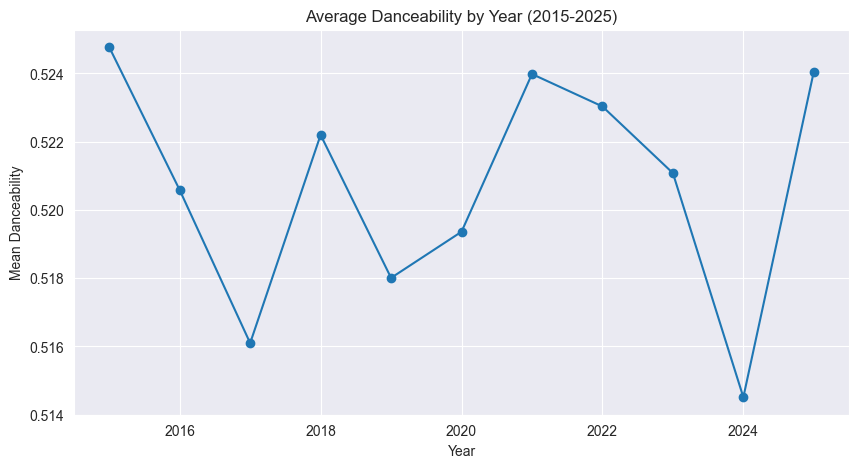

In [22]:
# visualization
plt.figure(figsize=(10, 5))
plt.plot(yearly_features["release_year"],
         yearly_features["danceability"],
         marker="o")
# marker="o" indicates that a circular marker is displayed at the data point location.


plt.title("Average Danceability by Year (2015-2025)")
plt.xlabel("Year")
plt.ylabel("Mean Danceability")
plt.grid(True)
plt.show()


## The temporal trend of dance music suitability
This graph shows the average dance music suitability of songs per year from 2015 to 2025. Each point is the average score of all songs in that year.
Overall, the trend is particularly stable, and there have been basically no major fluctuations in the past ten years. Although there will be a little ups and downs every year, the rhythm of mainstream Spotify songs, there is no noticeable change overall.
**This shows that even if platforms such as streaming media and TikTok affect the structure of songs, in the past ten years, the overall issue of whether the song is good or not to dance has been very stable.**
However, it is impossible to determine whether these small fluctuations are truly statistically significant. So next, I will use linear regression to verify whether these changes are random fluctuations or if there is really a statistically significant time trend.

## Linear regression analysis

In [27]:
# Linear regression analysis((Rely on the code in the notebook for the fifth week)
x = yearly_features["release_year"]
y = yearly_features["danceability"]

slope, intercept, r, p, std_err = st.linregress(x, y)

print("Slope:", slope)
print("Correlation (r):", r)
print("p-value:", p)

Slope: -4.792682928791829e-05
Correlation (r): -0.04690025614553071
p-value: 0.891086135366653


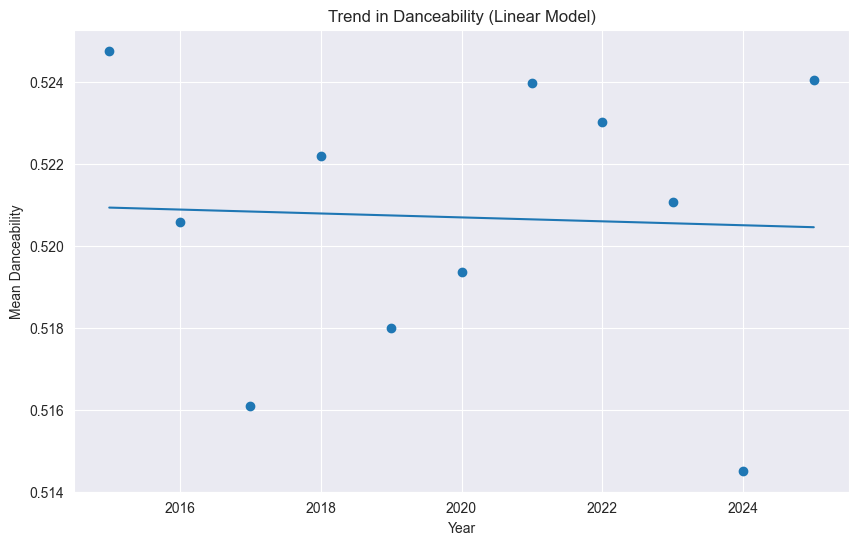

In [29]:
# draw linear regression
model_y = slope * x + intercept

plt.figure(figsize=(10,6))
plt.scatter(x, y)
plt.plot(x, model_y)

plt.title("Trend in Danceability (Linear Model)")
plt.xlabel("Year")
plt.ylabel("Mean Danceability")
plt.grid(True)
plt.show()

### Linear Regression Results(The following summary combines the data given by ChatGPT)

A linear regression was used to examine whether danceability changed between 2015 and 2025.

The Pearson correlation coefficient between release year and mean `danceability` is **r = -0.047**, indicating an extremely weak negative relationship. In practical terms, this suggests that `danceability` has remained largely stable across the decade.

The statistical significance test further confirms this observation. The regression produces a **p-value of 0.891**, which is far above the conventional significance threshold of 0.05. Therefore, the null hypothesis cannot be rejected, and there is no statistical evidence that `danceability` has systematically changed over time.

The `coefficient` of determination (R² ≈ 0.002) indicates that release year explains only about **0.2% of the variation in danceability**, which is effectively negligible.

Visually, the scatter plot also shows that the yearly average values fluctuate within a narrow range (approximately 0.515–0.525). While minor variations occur from year to year, the regression line remains nearly flat, reinforcing the conclusion that no meaningful temporal trend is present.

Overall, the analysis suggests that the rhythmic accessibility of mainstream Spotify tracks has remained structurally stable between 2015 and 2025.

# 4. What predicts Track Popularity?
In the previous sections (1-3), I examined whether audio characteristics exhibit long-term changes over time. In this section, I'll shift my focus to predictions:**Which features are most relevant to song popularity on Spotify?**

# 4.1 Baseline Model: Popularity ~ log10(stream_count)

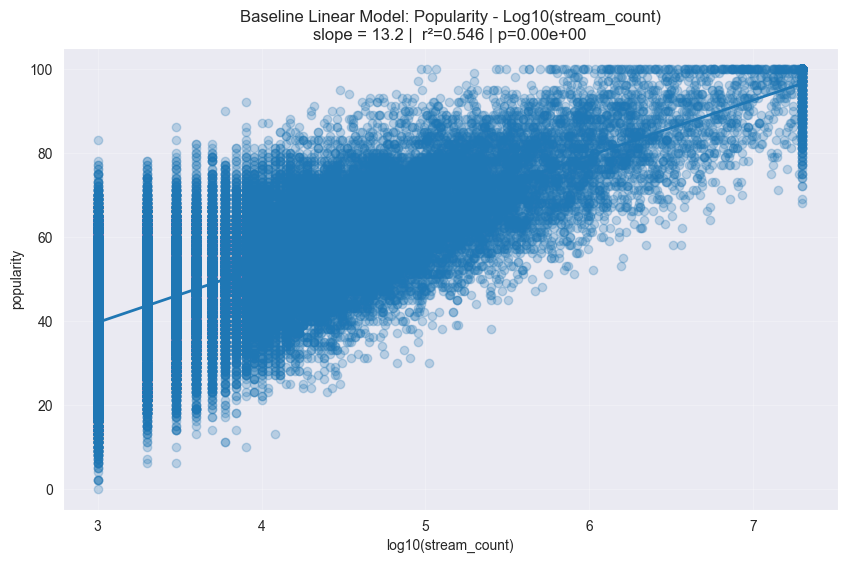

slope:  13.22974207265608
intercept:  -0.12090781322788047
r:  0.7387890843310966
r²:  0.5458093111267801
p_value:  0.0


In [22]:
# Baseline(Rely on the code in the notebook for the fifth week)
data = df_analysis[["log_stream_count", "popularity"]].dropna().values
x = data[:, 0]      # log10(stream_count)
y = data[:, 1]      # popularity

slope, intercept, r, p, std_err = st.linregress(x, y)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.25)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, linewidth = 2)

plt.title(f"Baseline Linear Model: Popularity - Log10(stream_count)\n"
          f"slope = {slope:.3g} |  r²={r**2:.3f} | p={p:.2e}")
plt.xlabel("log10(stream_count)")
plt.ylabel("popularity")
plt.grid(True, alpha=0.25)
plt.show()

print("slope: ", slope)
print("intercept: ", intercept)
print("r: ", r)
print("r²: ", r**2)
print("p_value: ", p)

## Baseline chart analysis(The following summary combines the data given by ChatGPT)
This scatter plot shows a clear positive linear relationship between `popularity` and `log10(stream_count)`: the regression **slope is about 13.23**, which means that for every 10-fold increase in playback volume (log10 +1). The correlation coefficient r≈0.739 and the coefficient of determination **r²≈0.546** indicate that about 54.6% of the `popularity` variation can be explained by `log_stream_count` alone. **A very small p-value (shown as 0) indicates that the relationship is highly significant.** Overall, this baseline is strong and provides a reference for subsequent tests of whether audio features can provide additional explanatory power.

# 4.2 Single-Feature Models: Popularity - Each Audio Feature
Outside of the baseline, the explanatory power (r²) and significance (p) of each audio feature for popularity are tested individually to find the features that have the most potential to enter the multivariate model.(ChatGPT has made some modifications after the error in the following code)

In [29]:
# Single-Feature Models: Popularity - Each Audio Feature
'''
The regression logic follows the Week 5 notebook, where two variables are extracted as x and y and analysed using scipy.stats.linregress(). Here, I extend that structure by looping through multiple candidate features so that each variable can be tested against popularity under the same regression framework.
'''
features = ["danceability", "energy", "tempo", "instrumentalness", "loudness"]
rows = []
for feat in features:
    tmp = df_analysis[[feat, "popularity"]].dropna()
    x = tmp[feat].values
    y = tmp["popularity"].values

    slope, intercept, r, p, std_err = st.linregress(x, y)

    rows.append({
        "feature": feat,
        "n": len(tmp),
        "slope": slope,
        "intercept": intercept,
        "r": r,
        "r²": r**2,
        "p_value": p
    })

single_feature_table = (
     pd.DataFrame(rows)
    .sort_values(["r²", "p_value"], ascending=[False, True])
)
single_feature_table

,feature,n,slope,intercept,r,r²,p_value
4,loudness,84979,0.00308,48.24947,0.00324,0.00001,0.34433
0,danceability,84979,0.17361,48.07272,0.00317,0.00001,0.35541
2,tempo,84979,-0.00101,48.29448,-0.00276,0.00001,0.42165
3,instrumentalness,84979,0.14784,48.10402,0.00231,0.00001,0.50115
1,energy,84979,-0.01947,48.17296,-0.00037,0.00000,0.91471


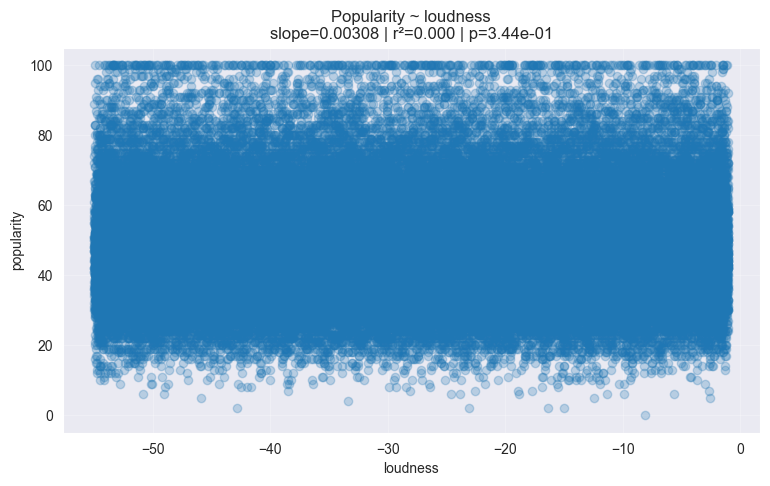

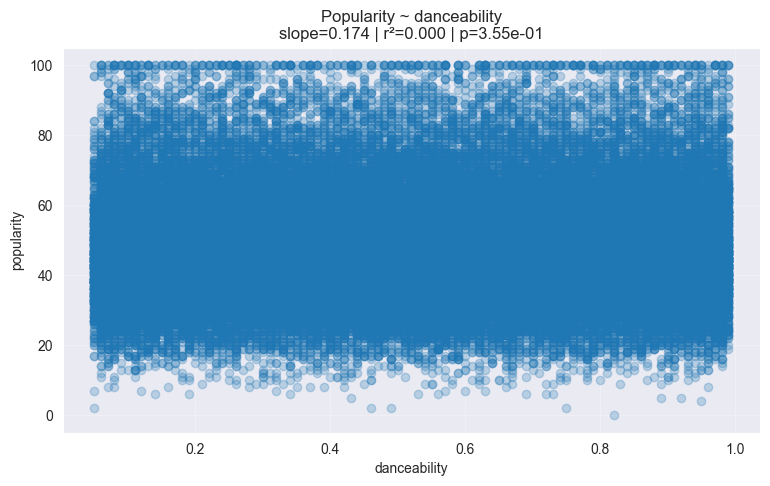

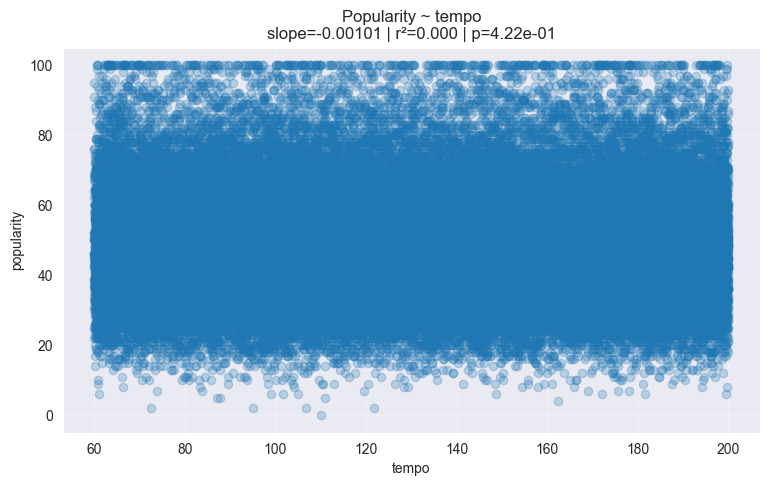

In [30]:
# Top 3 Visualizations
top3 = single_feature_table.head(3)["feature"].tolist()

for feat in top3:
    tmp = df_analysis[[feat, "popularity"]].dropna()
    x = tmp[feat].values
    y = tmp["popularity"].values
    slope, intercept, r, p, std_err = st.linregress(x, y)

    plt.figure(figsize=(9,5))
    plt.scatter(x, y, alpha=0.25)
    x_line = np.linspace(x.min(), x.max(), 200)
    plt.plot(x_line, slope * x_line + intercept, linewidth=2)
    plt.title(f"Popularity ~ {feat}\n"
              f"slope={slope:.3g} | r²={r**2:.3f} | p={p:.2e}")
    plt.xlabel(feat)
    plt.ylabel("popularity")
    plt.grid(True, alpha=0.25)
    plt.show()

## Top 3 Visualizations analysis(`single_feature_table`)
These three graphs further illustrate that the linear explanation of `popularity` by individual audio features is very weak. Whether it is `loudness`, `danceability`, or `tempo`, the scatters show highly dispersed "horizontal clouds", with the regression line almost flat, and the r² is close to 0, and the p-value is not significant. This suggests that these characteristics alone are not effective predictors of song popularity, in contrast to the strong baseline model of the previous `log_stream_count`.
Since a single audio feature has little explanatory power, the next step is to move on to multivariate regression to test whether they collectively improve the predictive power of `popularity` when multiple features are included in the model at the same time, and whether they still contribute independently after controlling for `log_stream_count`.

# 4.3 Multiple Linear Regression: Can audio features improve popularity prediction?

In [35]:
# linear_model.LinearRegression()
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

# Select relevant columns and remove missing values
df_multi = df_analysis[[
    "popularity",
    "danceability",
    "energy",
    "tempo",
    "instrumentalness",
    "loudness",
    "log_stream_count"
]].dropna()

# Select features
x = df_multi[[
    "danceability",
    "energy",
    "tempo",
    "instrumentalness",
    "loudness",
    "log_stream_count"
]]

# Target variable
y = df_multi["popularity"]

# Fit multiple regression model
regr = linear_model.LinearRegression()
regr.fit(x, y)

# Print coefficients, intercept, and R² score
print("Coefficients:", regr.coef_)
print("Intercept:", regr.intercept_)
print("R² score:", regr.score(x, y))

print("\nModel interpretation:")
print(
    f"Popularity = "
    f"{regr.coef_[0]:.4f} × danceability + "
    f"{regr.coef_[1]:.4f} × energy + "
    f"{regr.coef_[2]:.4f} × tempo + "
    f"{regr.coef_[3]:.4f} × instrumentalness + "
    f"{regr.coef_[4]:.4f} × loudness + "
    f"{regr.coef_[5]:.4f} × log_stream_count + "
    f"{regr.intercept_:.2f}"
)

Coefficients: [ 0.03585298 -0.07892851 -0.00002534  0.18368564  0.00019688 13.22976191]
Intercept: -0.16438457803786832
R² score: 0.5458202303074042

Model interpretation:
Popularity = 0.0359 × danceability + -0.0789 × energy + -0.0000 × tempo + 0.1837 × instrumentalness + 0.0002 × loudness + 13.2298 × log_stream_count + -0.16


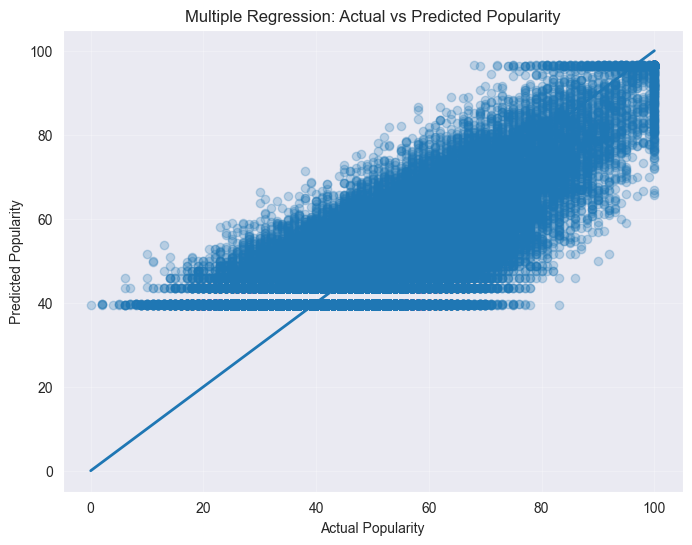

In [36]:
# linear_model.LinearRegression() visualization (Check how well the model fits overall)
y_pred = regr.predict(x)

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.25)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linewidth=2)

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title('Multiple Regression: Actual vs Predicted Popularity')
plt.grid(True, alpha=0.25)
plt.show()

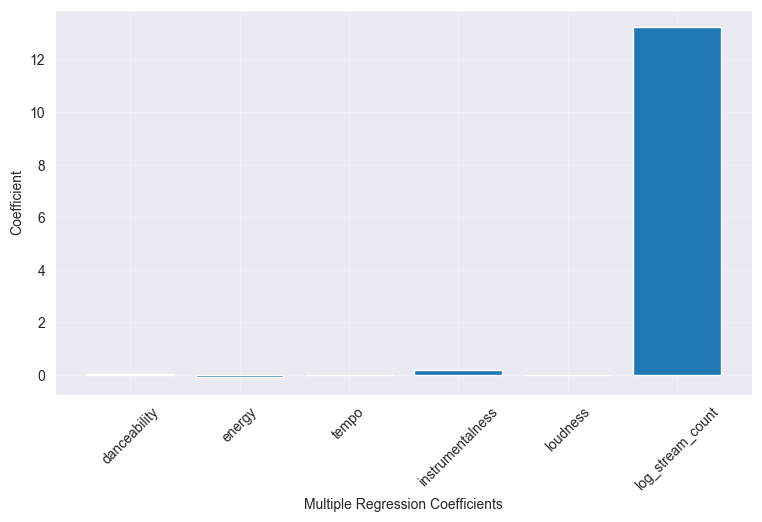

In [37]:
# Coefficient Bar Chart (Check The independent contribution direction and size of each variable)
coef_table = pd.DataFrame({
    "feature": x.columns,
    "coefficient": regr.coef_
})

plt.figure(figsize=(9, 5))
plt.bar(coef_table["feature"], coef_table["coefficient"])
plt.xticks(rotation=45)
plt.ylabel("Coefficient")
plt.xlabel("Multiple Regression Coefficients")
plt.grid(True, alpha=0.25)
plt.show()

## Multiple Linear Regression analysis(The following summary combines the data given by ChatGPT(like 54.6%))
Together, these graphs show that the multiple regression model has moderate explanatory power for `popularity`, with an overall **R² ≈ 0.546**, indicating that the model can explain about 54.6% of the popularity variation. From the `Actual vs Predicted` graph, most of the points are distributed diagonally, indicating that the model can better capture the overall trend, but there is still some error and compression in the lower `popularity` range. The `coefficient` results and bar graphs further show that `log_stream_count` is the overwhelming predictor, much higher than other audio features; In contrast, the `coefficients of danceability`, `energy`, `tempo`, and `loudness` are all very close to 0, with limited independent contributions, and `instrumentalness` is positive but has little impact. Overall, this shows that song popularity is primarily related to playback, and that audio characteristics alone provide less explanatory power when controlling for other variables.


# 4.4 Residual Plot
The next step is to perform residual plot (Q-Q Plot) to check whether there is a systematic pattern in the model error, so as to judge whether the assumption of linear regression is reasonable.m

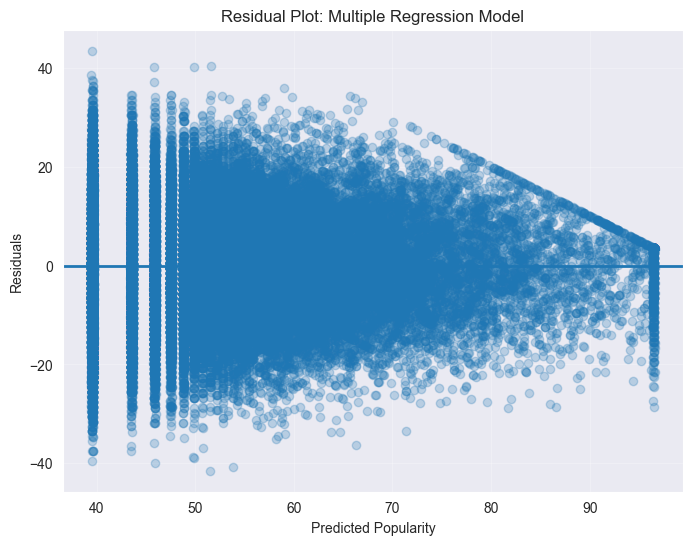

In [38]:
# Predicted values from multiple regression
y_pred = regr.predict(x)

# Residuals = actual - predicted
residuals = y - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.25)
plt.axhline(0, linewidth=2)

plt.xlabel("Predicted Popularity")
plt.ylabel("Residuals")
plt.title("Residual Plot: Multiple Regression Model")
plt.grid(True, alpha=0.25)
plt.show()

## Residual plot analysis(ChatGPT summary)
This residual plot shows that the errors of the multiple regression model are not completely randomly distributed, but show a certain **funnel/compression structure**. With the increase of prediction `popularity`, the fluctuation range of residuals gradually narrows, indicating that the error of the model in the high popularity range is smaller, while the fluctuation in the middle and low range is greater. At the same time, both the upper and lower boundaries of the residuals are limited by the popularity value range (0–100), which explains the pronounced triangle outline in the graph. Overall, this indicates that although the linear model can capture the main trend, **there are still certain heteroscedasticity and boundary effects,** **suggesting that the distribution feature of popularity and the upper limit constraint may limit the fitting performance of linear regression.**

# 4.5 Checking for Non-linearity / Saturation

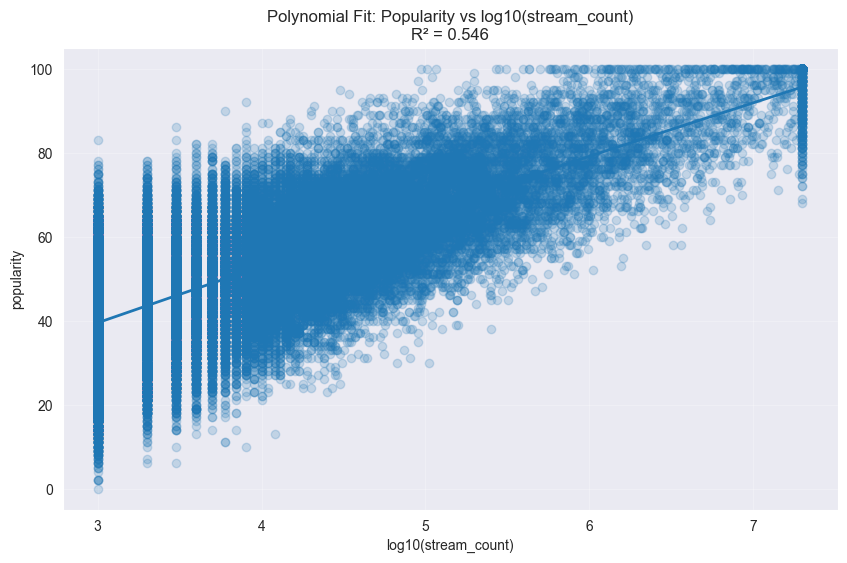

         2
-0.1177 x + 14.26 x - 2.242
r2 = 0.5458778154351805


In [42]:
# Check for non-linearity using a quadratic fit
x = df_analysis["log_stream_count"].values
y = df_analysis["popularity"].values

# fit quadratic model
num_degrees = 2
poly_model = np.polyfit(x, y, num_degrees)
poly_model = np.poly1d(poly_model)

# r2 for quadratic fit
r2_poly = r2_score(y, poly_model(x))

# plot
plt.figure(figsize=(10,6))
plt.scatter(x, y, alpha=0.2)

model_x = np.linspace(min(x), max(x), 200)
model_y = poly_model(model_x)

plt.plot(model_x, model_y, linewidth=2)
plt.xlabel("log10(stream_count)")
plt.ylabel("popularity")
plt.title(f"Polynomial Fit: Popularity vs log10(stream_count)\nR² = {r2_poly:.3f}")
plt.grid(True, alpha=0.25)
plt.show()

print(poly_model)
print("r2 =", r2_poly)

## Polynomial model analysis
The polynomial fit does not meaningfully improve the model, as the **R² remains almost the same (0.546)**. This suggests that the relationship between log_stream_count and popularity is already well captured by a simple linear model, with only limited evidence of a strong saturation or non-linear effect.

# 5. Reflections and Limitations
between 2015 and 2025 and how they relate to track popularity. The results suggest that most audio features remained relatively stable over time at the yearly level, while popularity showed only a weak upward tendency. In the prediction section, log_stream_count emerged as by far the strongest predictor of popularity, whereas individual audio features had very limited explanatory power on their own.

However, several limitations should be noted. First, the dataset does not include all potentially relevant musical or contextual variables. Popularity is likely influenced not only by audio features, but also by artist reputation, recommendation systems, playlist placement, marketing, social media circulation, and cultural trends. This means the regression models capture only part of what drives track success. Second, the yearly aggregation used  was useful for reducing noise and identifying macro trends, but it may hide important variation within genres, regions, or labels. Although the grouped genre analysis partly addressed this, the overall averages still simplify a much more complex musical landscape.

**There are also methodological limitations.** The linear models assume that relationships are approximately linear, yet the residual plot suggests some heteroscedasticity and boundary effects, partly because Spotify popularity is bounded between 0 and 100. This means the model is useful for identifying broad tendencies, but it does not perfectly capture all patterns in the data. In addition, correlation and regression coefficients should not be interpreted as causal effects. For example, a strong relationship between stream count and popularity does not mean stream count directly causes popularity; both may reflect broader platform dynamics.

**Future work** could extend this analysis by adding categorical variables such as genre, country, and label directly into the prediction model, or by testing interaction effects. More advanced models, such as non-linear regression or tree-based methods, might also capture relationships that simple linear models miss. Finally, incorporating richer musical or cultural features—such as lyrics, mood, playlist context, or artist-level metadata—would provide a fuller picture of how popularity is shaped in the streaming era.

Overall, the analysis suggests that while the sonic profile of mainstream Spotify music has remained broadly stable over the past decade, track popularity is shaped much more strongly by platform-level performance indicators than by any single audio feature alone.m